# FAPE - FairGround Corpus Stage 2: ThresholdOptimizer

Phase 4, Stage 2 cross-domain evaluation. The script applies Fairlearn's ThresholdOptimizer post-processing to five FairGround datasets under the demographic parity and equalized odds constraints: adult (income, race), compas_2_years (criminal justice, age, one group per year of age), creditcard (credit, sex), law_school_lequy (education, race as White / non-White, with sex kept as a feature) and meps_panel_19_fy2015 (healthcare, race). Features are the columns FairGround documents for each dataset (`Dataset.get_feature_columns`), minus the target, the sensitive attribute and the MEPS survey weight PERWT15F. For MEPS that is the standard 41-feature set, because the raw panel file also carries the office, outpatient, ER, inpatient and home-health counts that define the UTILIZATION label; compas_2_years likewise carries recidivism outcome columns outside its documented features. The DIR in Figure 8 is Fairlearn's `demographic_parity_ratio` (lowest group selection rate over highest), not a fixed-pair ratio. ThresholdOptimizer.predict is seeded (random_state=42), so runs are repeatable.

Code: `src/stage2_fairground_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_fairground_threshold import run_stage2

run_stage2()

FAPE Phase 4 - FairGround Stage 2: ThresholdOptimizer

--- Loading FairGround Corpus ---
FairGround corpus: 38 datasets available


  OK: adult: 32,560 rows | 14 features | sensitive: ['race']
  OK: arrhythmia: 451 rows | 279 features | sensitive: ['sex']
  OK: bank_additional_full: 41,188 rows | 20 features | sensitive: ['age']
  OK: bank_additional: 4,119 rows | 20 features | sensitive: ['age', 'marital']
  OK: bank_full: 45,211 rows | 16 features | sensitive: ['age', 'marital']
  OK: bank: 4,521 rows | 16 features | sensitive: ['age']


  OK: communities: 1,993 rows | 127 features | sensitive: ['racePctAsian']
  OK: communities_unnormalized: 2,214 rows | 146 features | sensitive: ['pct12-21']
  OK: compas_2_years: 6,172 rows | 52 features | sensitive: ['age']
  OK: compas_2_years_violent: 4,743 rows | 53 features | sensitive: ['age']
  OK: compas: 11,757 rows | 46 features | sensitive: ['sex', 'age']
  OK: creditcard: 30,000 rows | 24 features | sensitive: ['SEX']
  OK: drug: 1,885 rows | 31 features | sensitive: ['ethnicity']


  OK: dutch: 60,420 rows | 11 features | sensitive: ['age']
  OK: german_credit: 1,000 rows | 20 features | sensitive: ['foreign_worker']
  OK: german_credit_numeric: 1,000 rows | 24 features | sensitive: ['age']
  OK: south_german_credit: 1,000 rows | 20 features | sensitive: ['age', 'foreign_worker']
  OK: german_credit_onehot: 1,000 rows | 64 features | sensitive: ['<= 25 years']
  OK: heart_disease: 303 rows | 13 features | sensitive: ['sex']
  FAIL: law_school_tensorflow: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the
  OK: law_school_lequy: 18,692 rows | 11 features | sensitive: ['racetxt', 'male']


  OK: meps_panel_19_fy2015: 15,830 rows | 1830 features | sensitive: ['RACE']


...

  EO GradientBoosting           ACC=0.799(-0.061) EOD=0.039(-0.017)

--- Cross-Domain Fairness Summary ---
  Dataset                   Domain               Base DPD   DP DPD Base EOD   EO EOD
  adult                     Income                  0.122    0.169    0.667    0.444
  compas_2_years            Criminal Justice        1.000      nan    1.000      nan
  creditcard                Credit                  0.009    0.019    0.018    0.019
  law_school_lequy          Education               0.342    0.014    0.518    0.016
  meps_panel_19_fy2015      Healthcare              0.092    0.013    0.056    0.039

--- Key Findings (GB, DPD under the DP constraint) ---
  Lowest baseline DPD: creditcard | highest: compas_2_years
  adult                  0.122 -> 0.169 (-38.7% improvement)
  compas_2_years         DP constraint failed to fit
  creditcard             0.009 -> 0.019 (-103.9% improvement)
  law_school_lequy       0.342 -> 0.014 (+96.0% improvement)
  meps_panel_19_fy2015   0.092

Fig 2 saved - fairground_dpd_before_after.png
Fig 3 saved - fairground_eod_before_after.png


Fig 4 saved - fairground_cost_gain.png
Fig 5 saved - fairground_accuracy_comparison.png


Fig 6 saved - fairground_fairness_improvement_pct.png
Fig 7 saved - fairground_permodel_dpd_improvement.png


Fig 8 saved - fairground_dir_before_after.png

--- FairGround Stage 2 complete ---
  8 figures saved to figures/stage2/


## 1. Baseline DPD by dataset

Baseline demographic parity difference for each model on each dataset's own sensitive attribute.

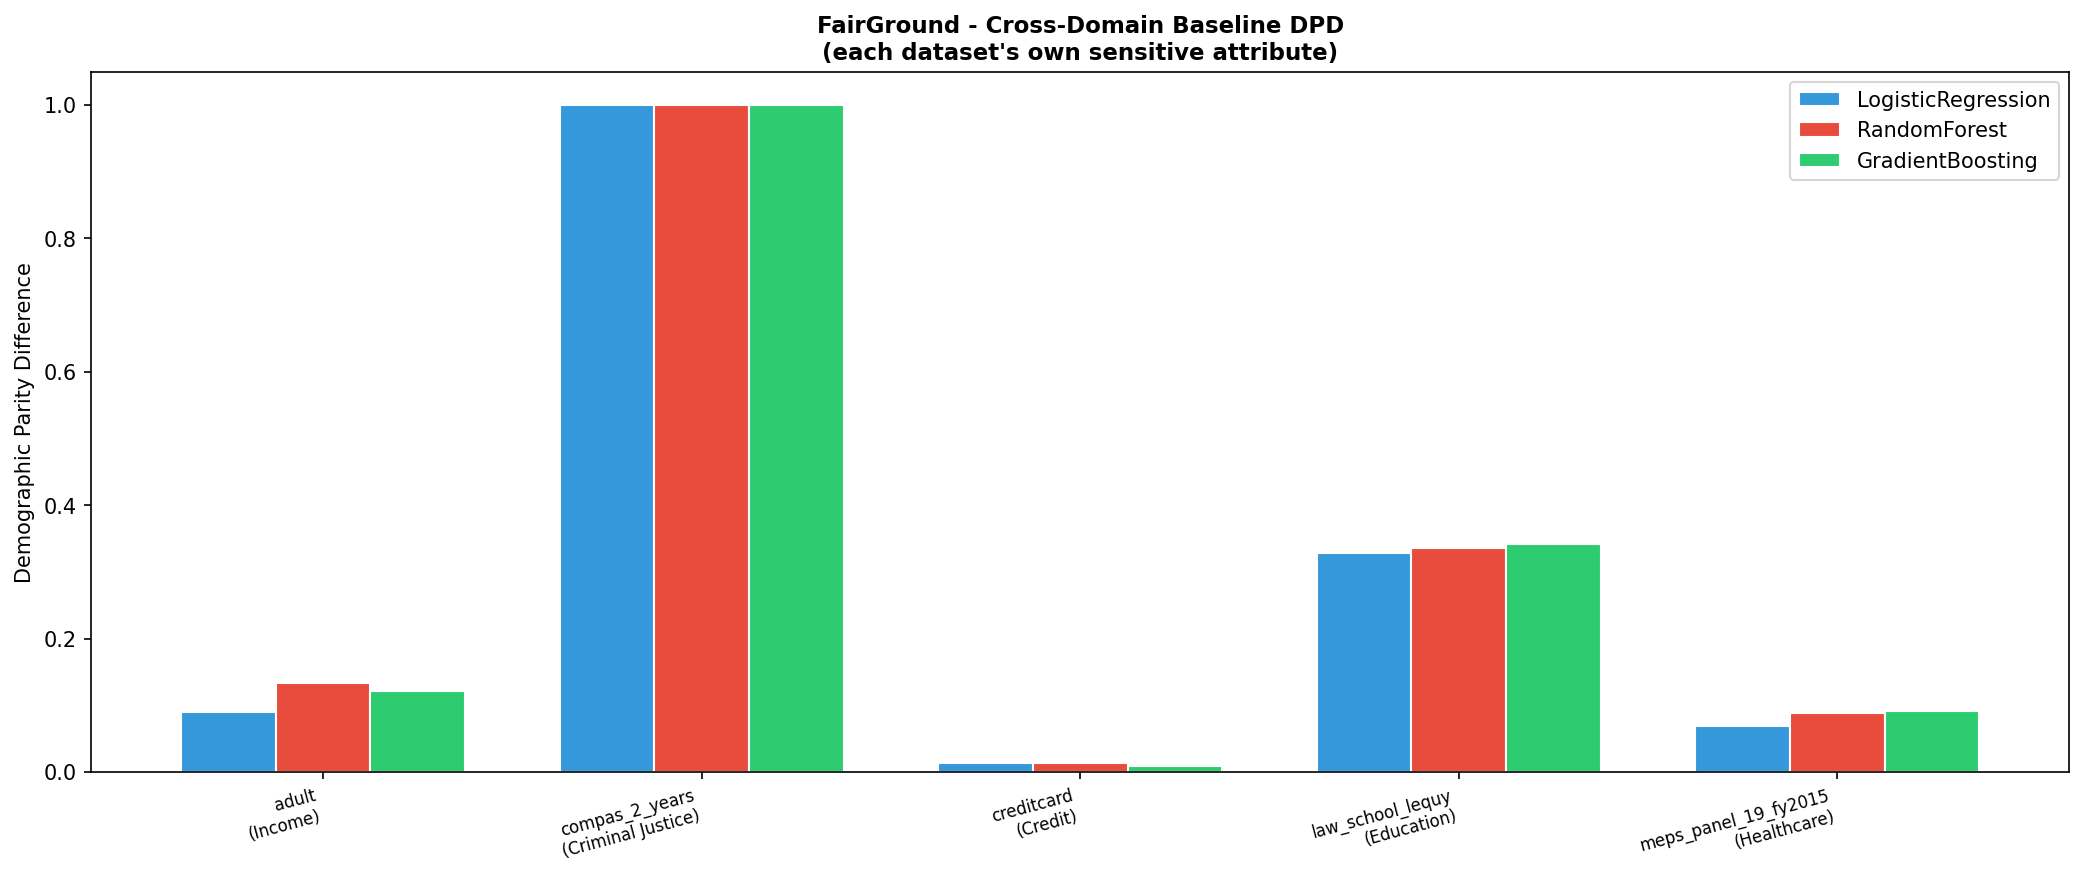

In [3]:
display(Image('figures/stage2/fairground_baseline_dpd.png'))

## 2. DPD before and after the demographic parity constraint

Gradient boosting's DPD at baseline and after the demographic parity constraint, by dataset.

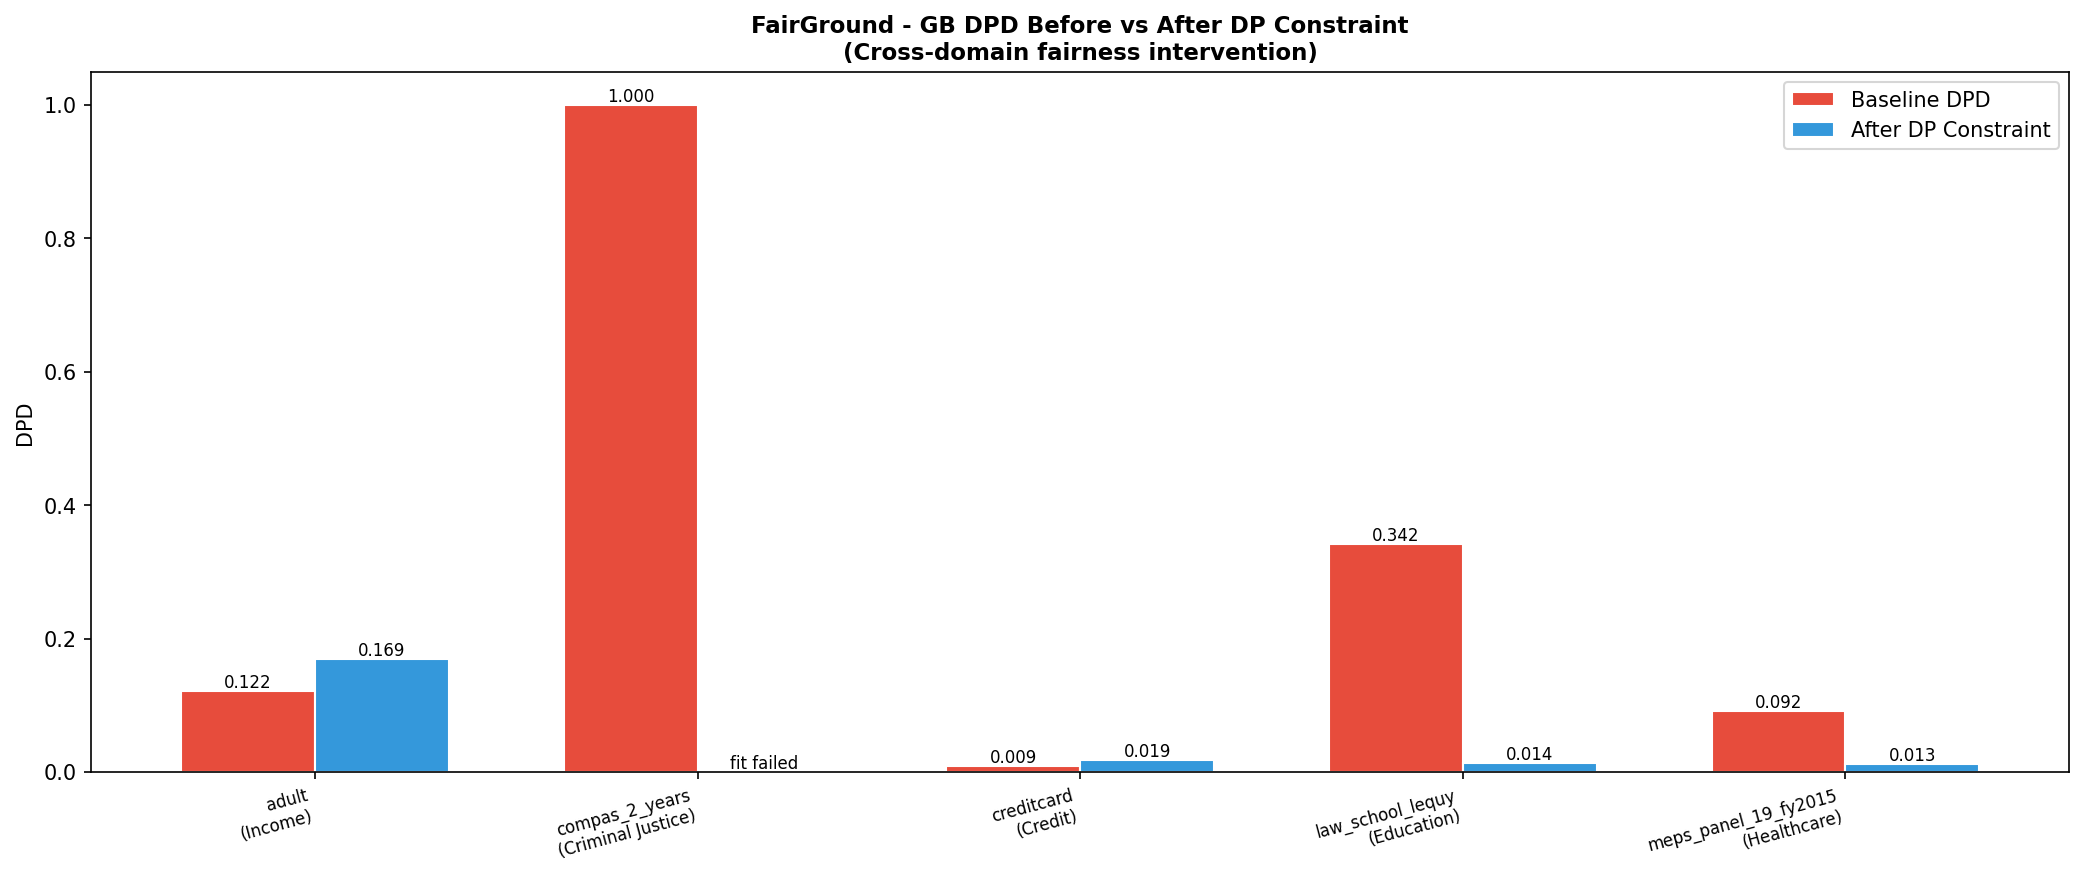

In [4]:
display(Image('figures/stage2/fairground_dpd_before_after.png'))

## 3. EOD before and after the equalized odds constraint

Gradient boosting's EOD at baseline and after the equalized odds constraint, by dataset.

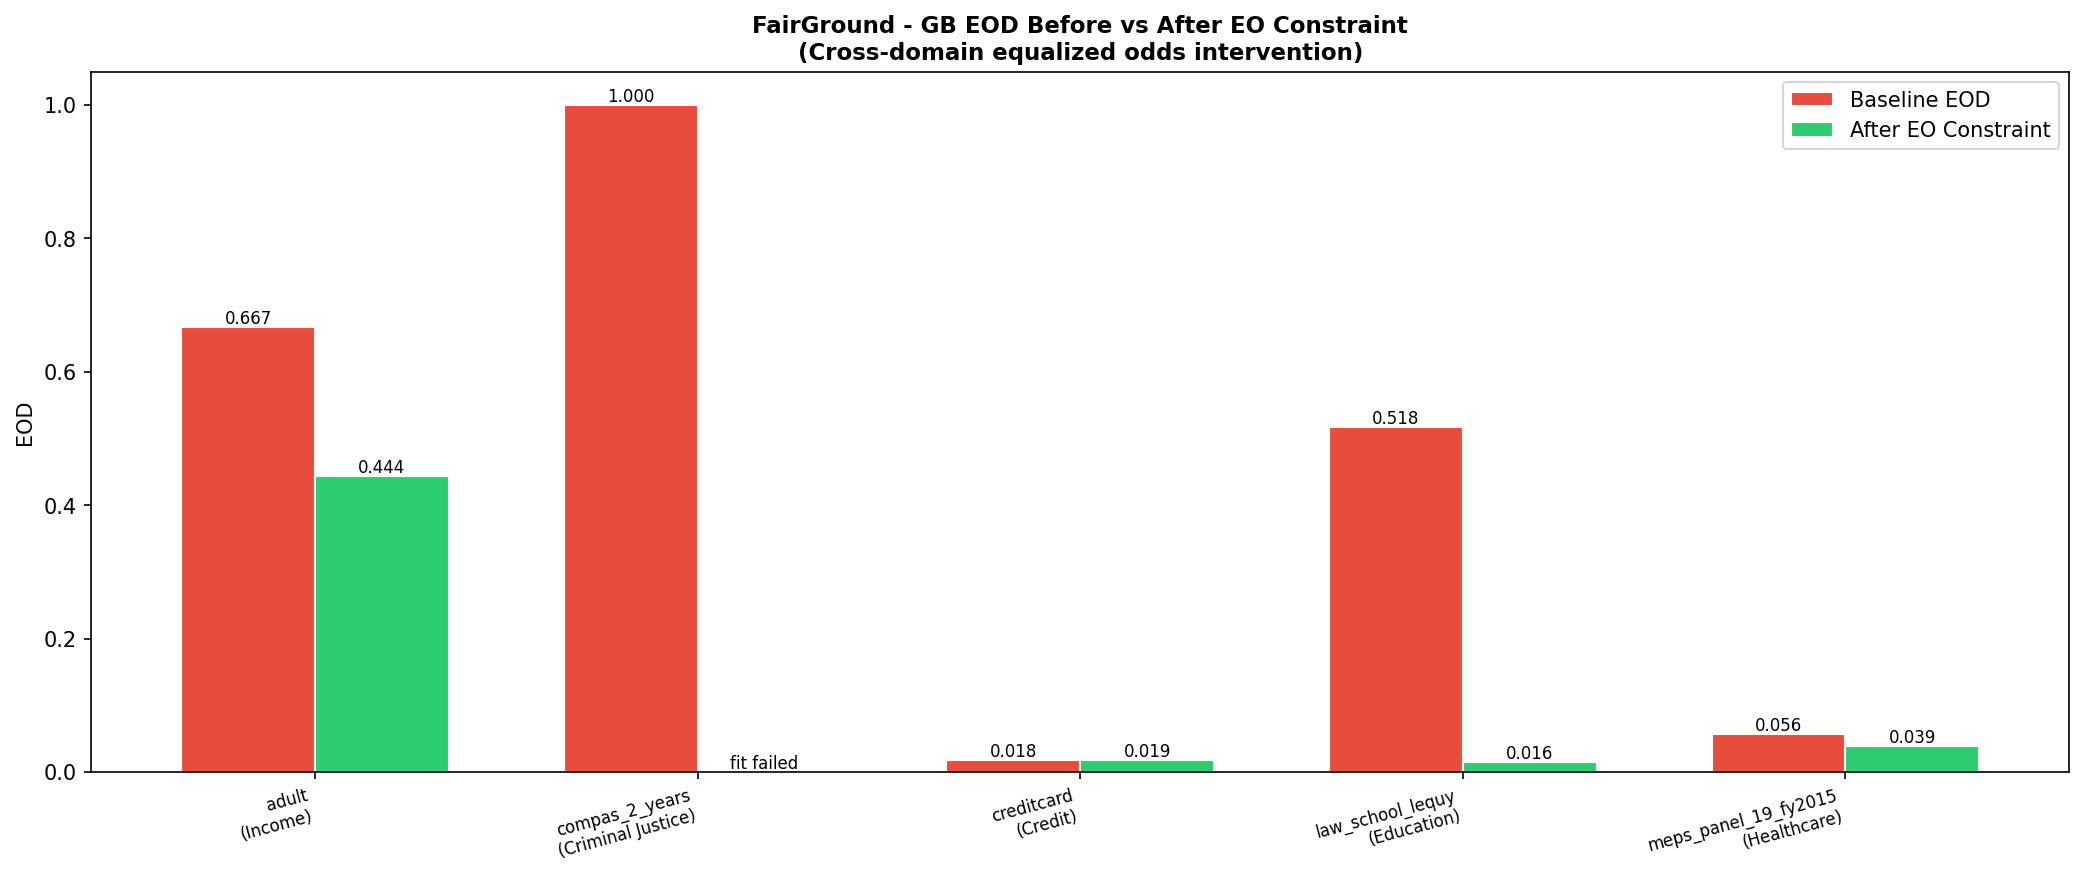

In [5]:
display(Image('figures/stage2/fairground_eod_before_after.png'))

## 4. Accuracy cost against fairness gain

Gradient boosting's accuracy cost plotted against its fairness gain under each constraint, by domain.

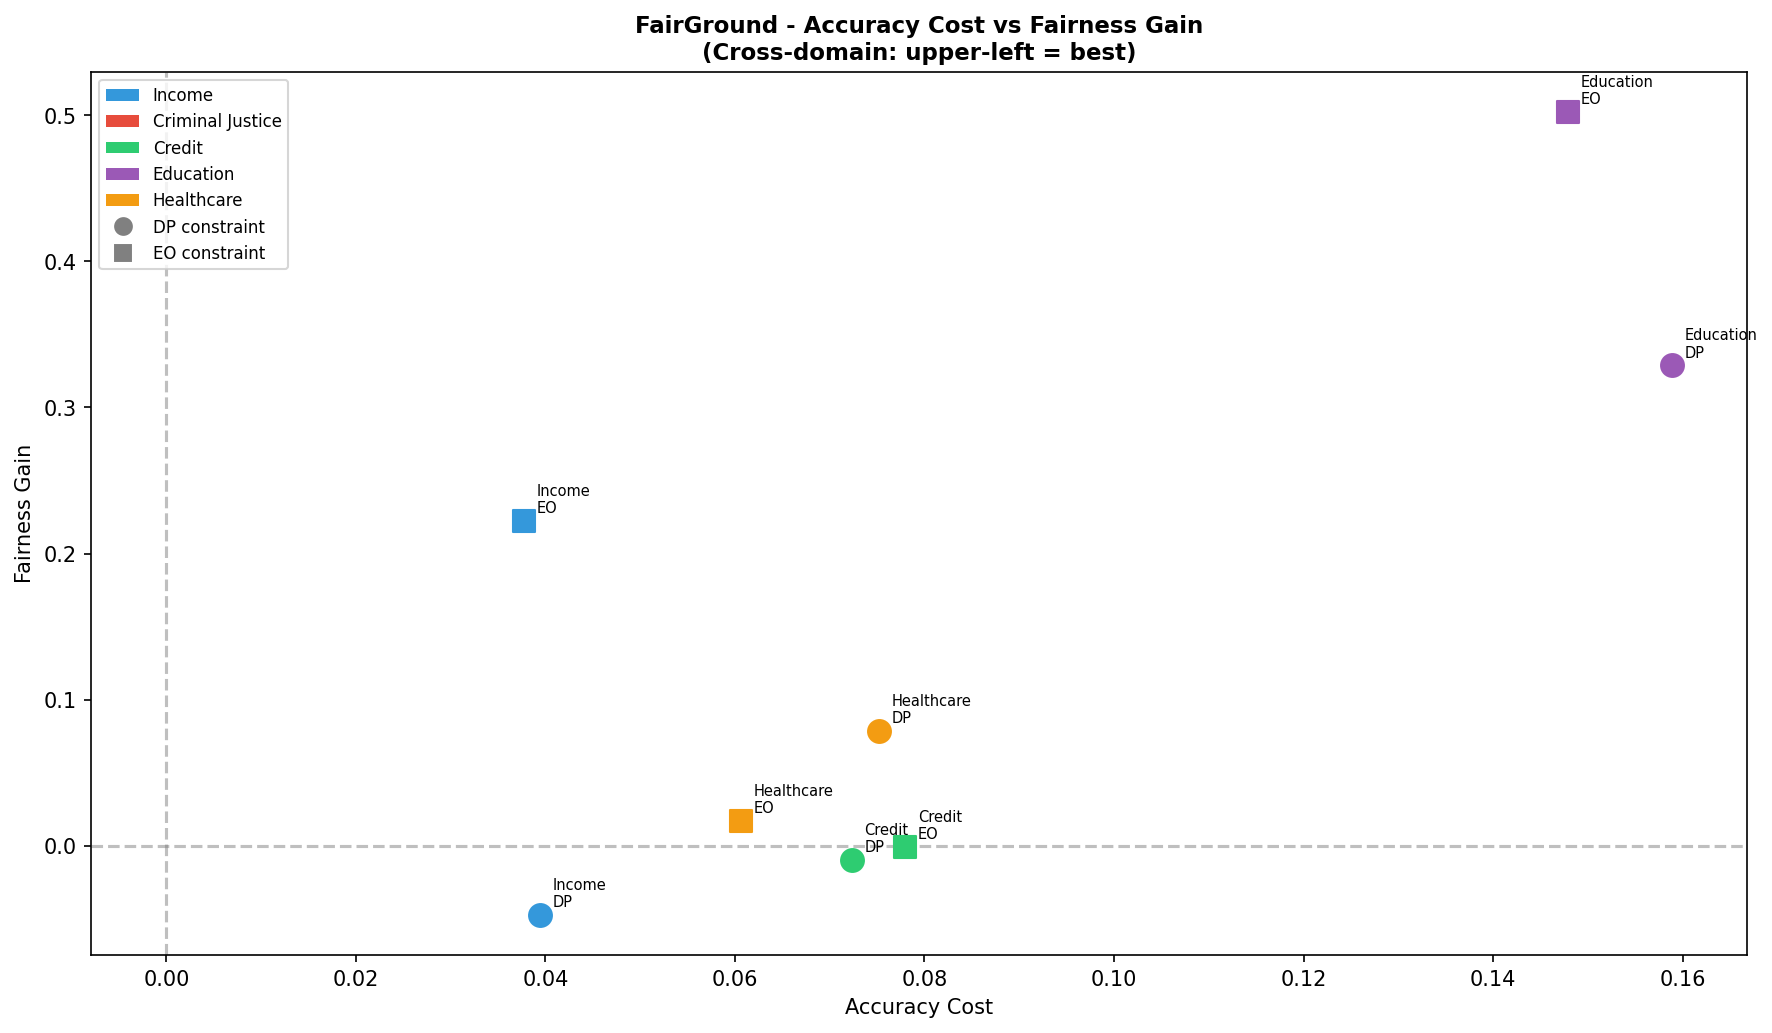

In [6]:
display(Image('figures/stage2/fairground_cost_gain.png'))

## 5. Accuracy by dataset

Gradient boosting's accuracy at baseline and under each constraint, by dataset.

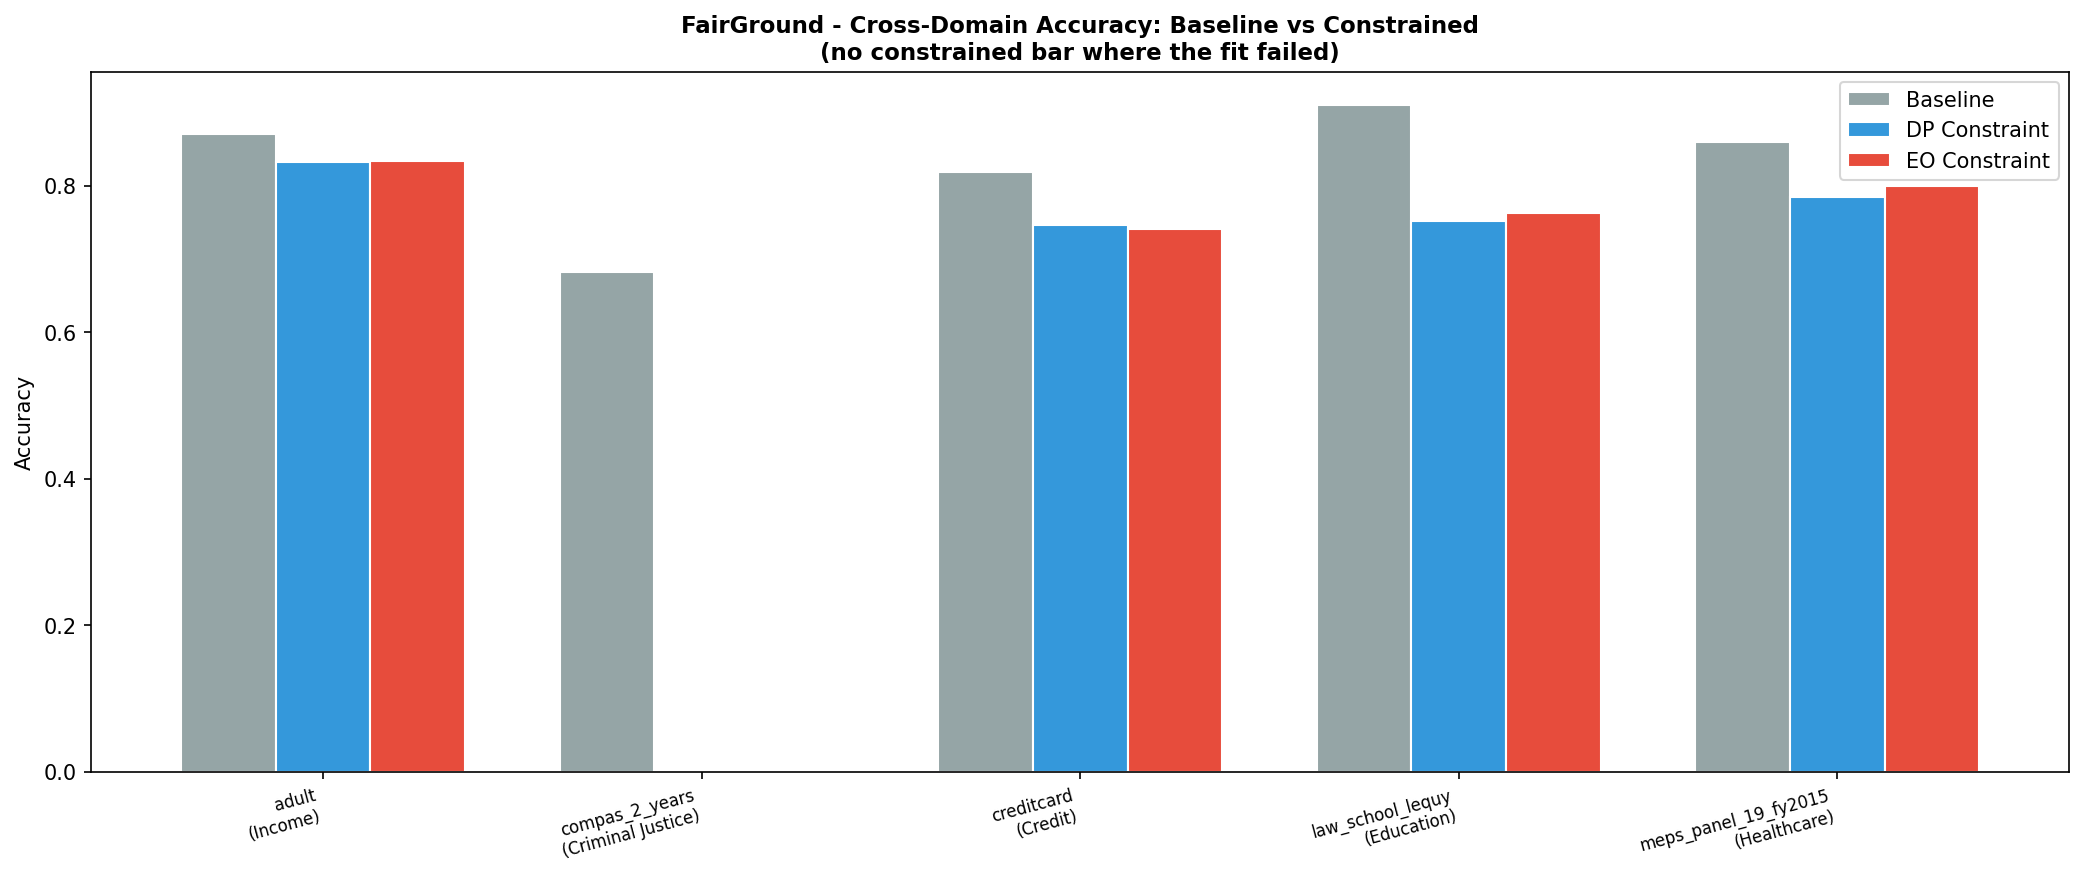

In [7]:
display(Image('figures/stage2/fairground_accuracy_comparison.png'))

## 6. Percentage change by domain

Gradient boosting's percentage change in DPD under the demographic parity constraint and in EOD under the equalized odds constraint.

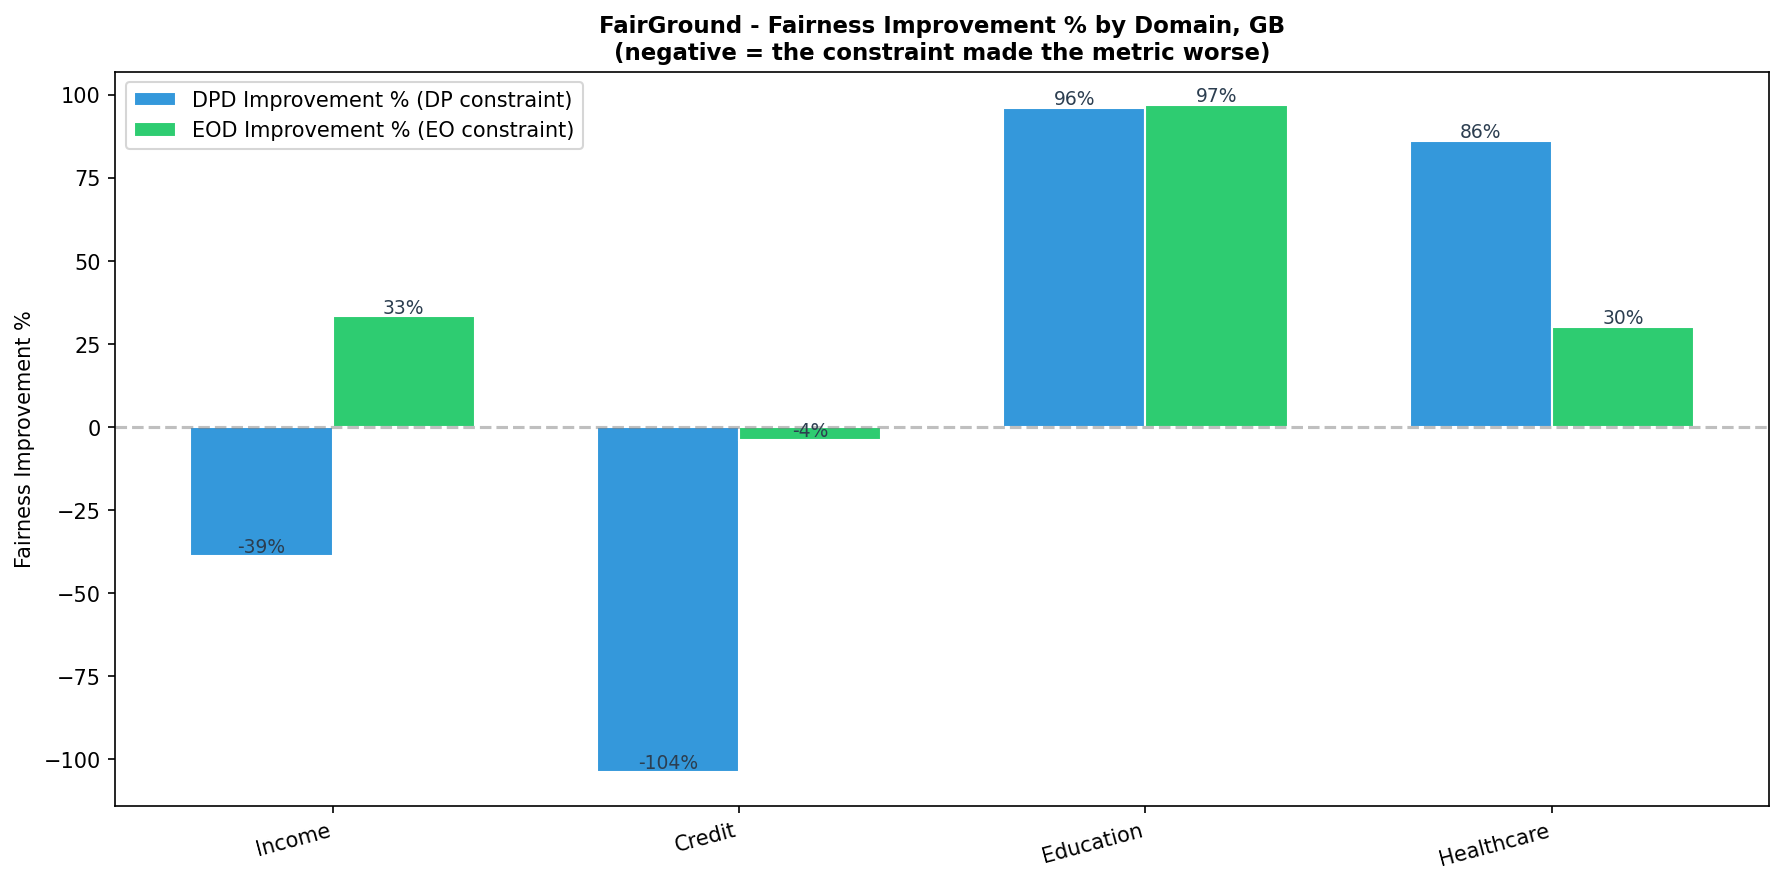

In [8]:
display(Image('figures/stage2/fairground_fairness_improvement_pct.png'))

## 7. DPD reduction by model

Reduction in DPD under the demographic parity constraint for each model, by domain.

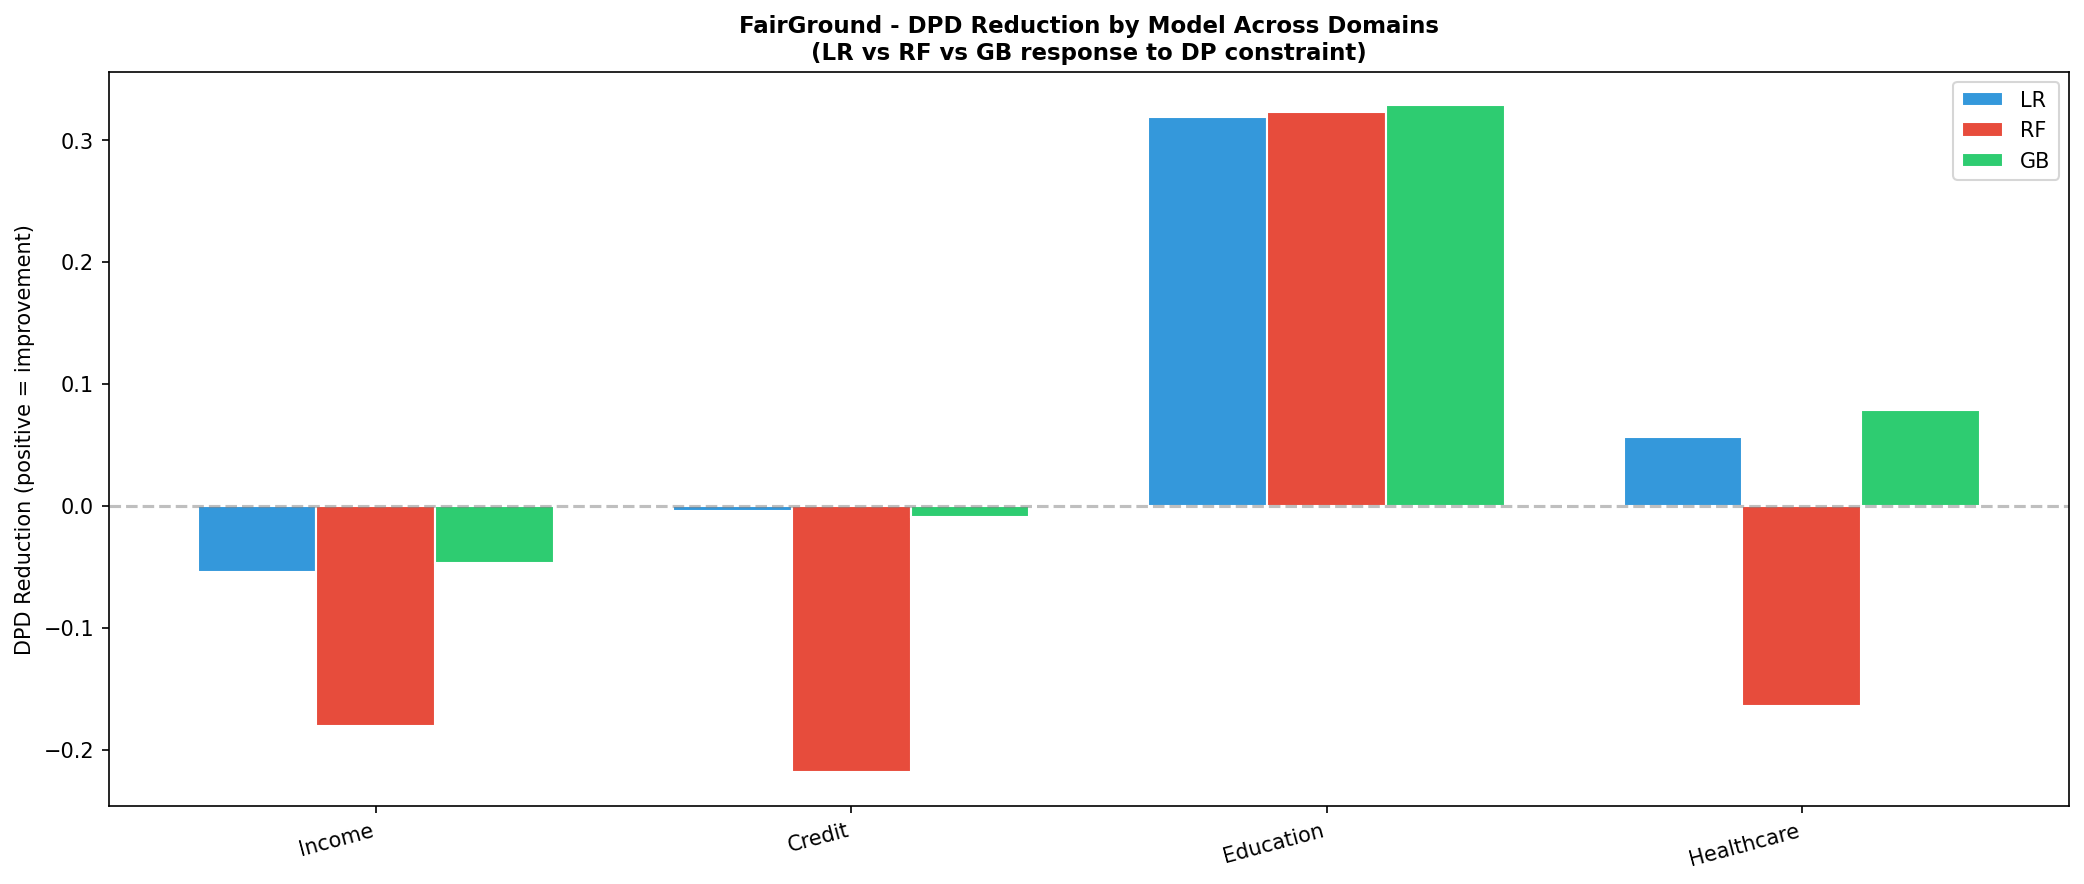

In [9]:
display(Image('figures/stage2/fairground_permodel_dpd_improvement.png'))

## 8. Selection-rate ratio before and after the demographic parity constraint

Fairlearn's demographic parity ratio for gradient boosting, before and after the demographic parity constraint, by domain.

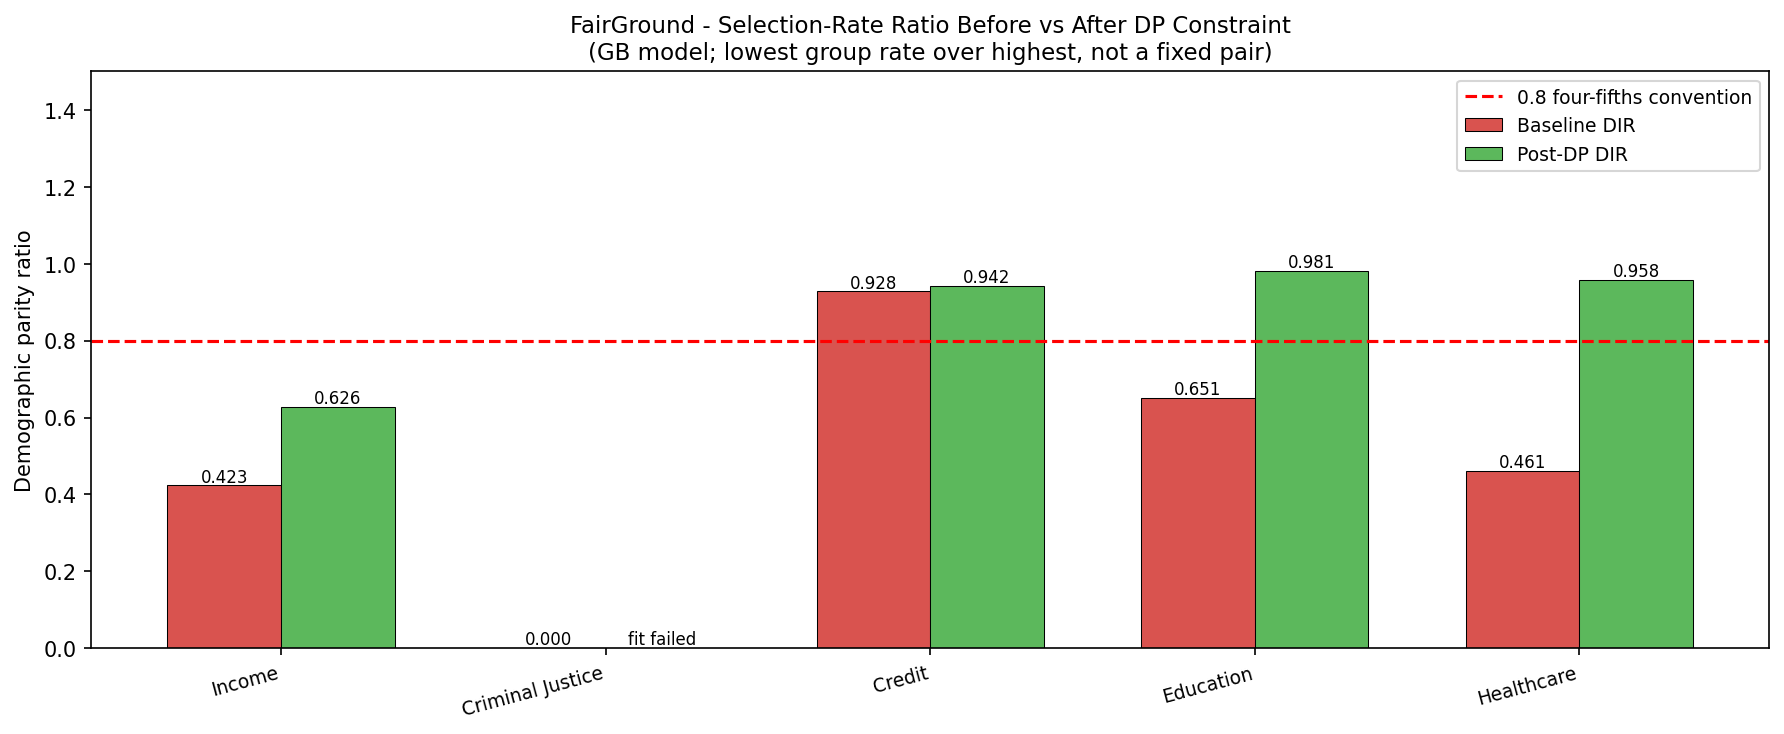

In [10]:
display(Image('figures/stage2/fairground_dir_before_after.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.